In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yfin
from datetime import date, datetime

pd.options.display.float_format = "{:,.6f}".format
sns.set_theme()

#### Data Wrangling


In [235]:
start = date(2019, 1, 1)
end = datetime.now().date()

In [236]:
# df = yfin.download(["AMZN", "F", "BTC-USD"], start, end, auto_adjust = False)["Adj Close"]

In [237]:
df = pd.read_csv("FD_M2_L1_stocks_data.csv", index_col="Date", parse_dates=True)
df.index = df.index.tz_localize("UTC")

#### Understanding the data


In [238]:
df.head()

,AMZN,BTC-USD,F
Date,,,
2019-01-01 00:00:00+00:00,NaN,"3,843.520020",NaN
2019-01-02 00:00:00+00:00,76.956497,"3,943.409424",5.399677
2019-01-03 00:00:00+00:00,75.014000,"3,836.741211",5.317656
2019-01-04 00:00:00+00:00,78.769501,"3,857.717529",5.522707
2019-01-05 00:00:00+00:00,NaN,"3,845.194580",NaN


In [239]:
df.describe()

,AMZN,BTC-USD,F
count,"1,885.000000","2,740.000000","1,885.000000"
mean,154.379548,"43,677.597943",9.485997
std,48.301164,"32,293.534063",2.730986
min,75.014000,"3,399.471680",2.972524
25%,108.919998,"16,159.361816",7.101004
50%,157.238998,"36,824.865234",9.768817
75%,185.130005,"65,451.939453",11.183978
max,274.989990,"124,752.531250",18.766813


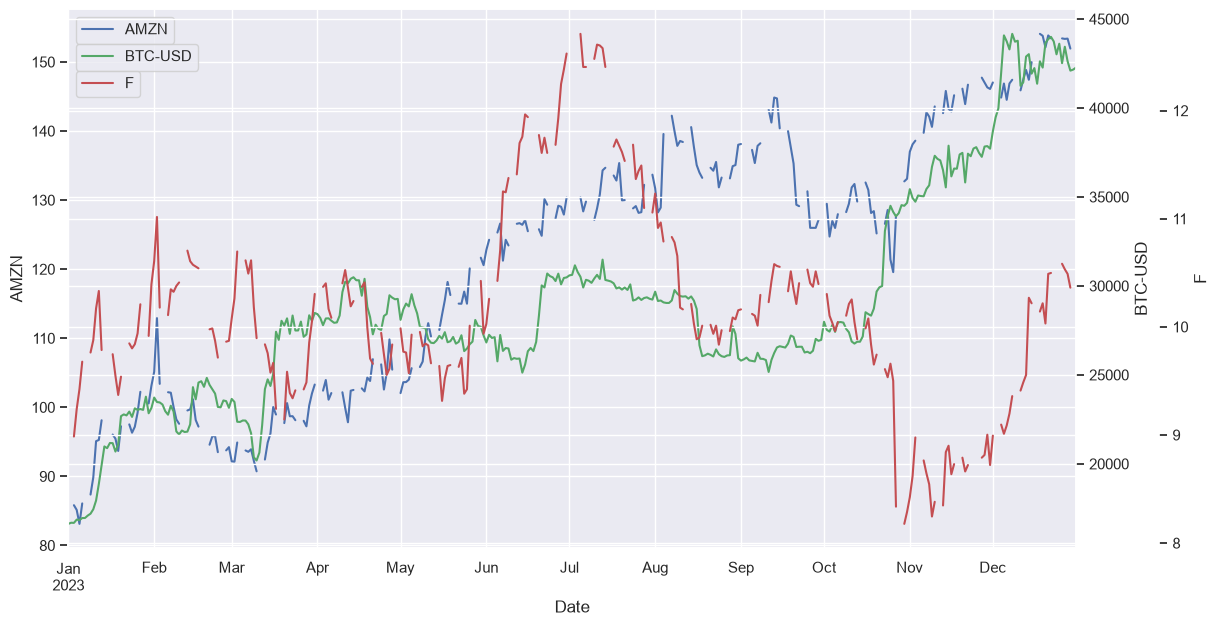

In [240]:
fig = plt.figure(figsize=(13, 7))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()
ax3 = ax1.twinx()
# Plot the data
df["2023-01-01":"2023-12-31"].plot(ax=ax1, y="AMZN", legend=True)
df["2023-01-01":"2023-12-31"].plot(ax=ax2, y="BTC-USD", legend=True, color="g")
df["2023-01-01":"2023-12-31"].plot(ax=ax3, y="F", legend=True, color="r")
# We set the labels to the axes
ax1.set_ylabel("AMZN")
ax2.set_ylabel("BTC-USD")
ax3.set_ylabel("F")
ax3.spines["right"].set_position(("outward", 60))
# Set position of legend

ax1.legend(["AMZN"], loc="upper left")
ax2.legend(["BTC-USD"], loc="upper left", bbox_to_anchor=(0,0.95))
ax3.legend(["F"], loc="upper left", bbox_to_anchor=(0,0.9))
plt.show()

### Quantitative Aanalysis

In [241]:
df = df.loc["2019-08-01": "2024-07-31"].copy()

If we invested $1000 into each of these assets five years ago, how much money would we have today? To answer this quesion, we first need to determine how many shares of each stock we could by with $1000 at the start of our date range. 
We will use the values of the first row for each ticker stored in individual variables, which can then use for futher calculations or analysis

In [242]:
first_row = df.iloc[0] 
first_row

AMZN          92.765999
BTC-USD   10,399.668945
F              6.676325
Name: 2019-08-01 00:00:00+00:00, dtype: float64

In [243]:
amzn_price = first_row["AMZN"]
f_price = first_row["F"]
btc_price = first_row["BTC-USD"]
print("Purchase price of AMZN:", np.round(amzn_price, 3))
print("Purchase price of F:", np.round(f_price, 3))
print("Purchase price of BTC-USD:", np.round(btc_price, 3))


Purchase price of AMZN: 92.766
Purchase price of F: 6.676
Purchase price of BTC-USD: 10399.669


In [244]:
#Shares
amzn_shares = 1000/amzn_price
f_shares = 1000/f_price
btc_shares = 1000/btc_price

# Print number of shares for each ticker
print("Number of shares of AMZN:", np.round(amzn_shares, 3))
print("Number of shares of F:", np.round(f_shares, 3))
print("Number of shares of BTC-USD:", np.round(btc_shares, 3))



Number of shares of AMZN: 10.78
Number of shares of F: 149.783
Number of shares of BTC-USD: 0.096


Now, to determine how much money we would have today, we look at the most recent date in our dataset (31/07/2024), get the prices of each asset, and multiply our number of shares by this number. We can find this by looking at the bottom of our dataset in using the *tail()* method. Alternatively, we can also program asset value computations:

In [245]:
last_row = df.iloc[-1]
last_row

AMZN         186.979996
BTC-USD   64,619.250000
F              9.560737
Name: 2024-07-31 00:00:00+00:00, dtype: float64

In [246]:
# Assign end date price values to variables
amzn_price_end = last_row["AMZN"]
f_price_end = last_row["F"]
btc_price_end = last_row["BTC-USD"]

# Print end date prices
print("End price of AMZN:", np.round(amzn_price_end, 3))
print("End price of F:", np.round(f_price_end, 3))
print("End price of BTC-USD:", np.round(btc_price_end, 3))
print(" - - - - - - - - - -")


End price of AMZN: 186.98
End price of F: 9.561
End price of BTC-USD: 64619.25
 - - - - - - - - - -


In [247]:
amzn_value = amzn_price_end * amzn_shares
f_value = f_price_end * f_shares
btc_value = btc_price_end * btc_shares

# Print end date values
print("Holding value of AMZN:", np.round(amzn_value, 3))
print("Holding value of F:", np.round(f_value, 3))
print("Holding value of BTC-USD:", np.round(btc_value, 3))


Holding value of AMZN: 2015.609
Holding value of F: 1432.036
Holding value of BTC-USD: 6213.587


It's important to remember that these are just the final values and don't tell the whole story. To get a clearer picture of investment performance, we need to consider:
 - Timeframe: We need to know the timeframe of this investment to assess the returns accurately. Short-term fluctuations are normal, while long-term trends are more indicative of overall performance.
 - External Factors: Market volatility, economic conditions, and company-specific news can significantly impact stock prices.
 - Investment Strategy: Your individual investment goals and risk tolerance should guide your decisions.

    Simple Returns

In [248]:
# Compute simple returns
amzn_return = (amzn_value - 1000) / 1000
f_return = (f_value - 1000) / 1000
btc_return = (btc_value - 1000) / 1000

# Print the returns
print("Simple return of AMZN:", np.round(amzn_return * 100, 3), "%")
print("Simple return of F:", np.round(f_return * 100, 3), "%")
print("Simple return of BTC-USD:", np.round(btc_return * 100, 3), "%")

Simple return of AMZN: 101.561 %
Simple return of F: 43.204 %
Simple return of BTC-USD: 521.359 %


#### Comparing Equities and Bitcoin to Bonds

##  **3. Comparing Equities and Bitcoin to Bonds**

Let's introduce one more asset class here: bonds. As you recall from the Financial Markets class, bonds not only have the return of principal, but they also return a coupon, usually annually or quarterly. To simplify things, we will use an exchange-traded fund (ETF), which tracks bonds. The ETF is the Vanguard Long-Term Bond Index Fund ETF or BLV for short. This fund intends to track the performance of the Bloomberg Barclays U.S. Long Government/Credit Float Adjusted Index. This index includes investment grade corporate, U.S. government, and international dollar-denominated bonds that have maturities greater than 10 years. At least 80% of the fund's total assets will be invested in bonds held in the index mentioned above (Vanguard).

In [249]:
# df = df.join(pd.read_csv('FD_M2_L1_stocks_data.csv', index_col='Date', parse_dates=True)\
#              .loc[start:end].reindex(columns=["BLV"]).tz_localize('UTC'))
df = df.join(yfin.download(["BLV"], start, end, auto_adjust = False)["Adj Close"].tz_localize('UTC'))
df

[*********************100%***********************]  1 of 1 completed


,AMZN,BTC-USD,F,BLV
Date,,,,
2019-08-01 00:00:00+00:00,92.765999,"10,399.668945",6.676325,72.614609
2019-08-02 00:00:00+00:00,91.162003,"10,518.174805",6.654810,73.123062
2019-08-03 00:00:00+00:00,NaN,"10,821.726562",NaN,NaN
2019-08-04 00:00:00+00:00,NaN,"10,970.184570",NaN,NaN
2019-08-05 00:00:00+00:00,88.256500,"11,805.653320",6.618955,73.749382
...,...,...,...,...
2024-07-27 00:00:00+00:00,NaN,"67,813.335938",NaN,NaN
2024-07-28 00:00:00+00:00,NaN,"68,255.867188",NaN,NaN
2024-07-29 00:00:00+00:00,183.199997,"66,819.914062",9.728624,65.275513


#### Calculate Log Returns, Remove Unused Columns and Drop Nulls

In [250]:
returns_stocks_BLV = df[['AMZN', 'F', 'BLV']].dropna().pct_change()
returns_BTC = df[['BTC-USD']].pct_change()

# We broadcast the index of crupto on the stocks in order to join the datasets
# Having NaN for weekends withing BLV columns

returns_stocks = returns_stocks_BLV.reindex(returns_BTC.index) # This will give BTC index to all the stock index. Then we can join them
returns_stocks.head(10)


,AMZN,F,BLV
Date,,,
2019-08-01 00:00:00+00:00,NaN,NaN,NaN
2019-08-02 00:00:00+00:00,-0.017291,-0.003222,0.007002
2019-08-03 00:00:00+00:00,NaN,NaN,NaN
2019-08-04 00:00:00+00:00,NaN,NaN,NaN
2019-08-05 00:00:00+00:00,-0.031872,-0.005388,0.008565
2019-08-06 00:00:00+00:00,0.012860,0.027086,0.006693
2019-08-07 00:00:00+00:00,0.003115,0.005274,0.001688
2019-08-08 00:00:00+00:00,0.022020,0.003148,0.003269
2019-08-09 00:00:00+00:00,-0.013809,-0.011506,-0.003555


In [251]:
returns = returns_BTC.join(returns_stocks_BLV, how="outer")[1:]
returns

,BTC-USD,AMZN,F,BLV
Date,,,,
2019-08-02 00:00:00+00:00,0.011395,-0.017291,-0.003222,0.007002
2019-08-03 00:00:00+00:00,0.028860,NaN,NaN,NaN
2019-08-04 00:00:00+00:00,0.013719,NaN,NaN,NaN
2019-08-05 00:00:00+00:00,0.076158,-0.031872,-0.005388,0.008565
2019-08-06 00:00:00+00:00,-0.027740,0.012860,0.027086,0.006693
...,...,...,...,...
2024-07-27 00:00:00+00:00,-0.001454,NaN,NaN,NaN
2024-07-28 00:00:00+00:00,0.006526,NaN,NaN,NaN
2024-07-29 00:00:00+00:00,-0.021038,0.003836,-0.016086,0.003785


#### Show summary stats for returns

In [252]:
returns.describe()

,BTC-USD,AMZN,F,BLV
count,"1,826.000000","1,257.000000","1,257.000000","1,257.000000"
mean,0.001579,0.000803,0.000671,-0.000034
std,0.033707,0.022175,0.027760,0.009179
min,-0.371695,-0.140494,-0.183614,-0.075169
25%,-0.013480,-0.011068,-0.013605,-0.005253
50%,0.000234,0.000643,0.000000,0.000571
75%,0.015996,0.012222,0.014212,0.005206
max,0.187465,0.135359,0.234414,0.049139


#### Converting daily returns to annual

In [254]:
returns.describe()[["BTC-USD","F"]]

,BTC-USD,F
count,"1,826.000000","1,257.000000"
mean,0.001579,0.000671
std,0.033707,0.027760
min,-0.371695,-0.183614
25%,-0.013480,-0.013605
50%,0.000234,0.000000
75%,0.015996,0.014212
max,0.187465,0.234414
